# AI and Text Analytics Coursework: Initial EDA

In [60]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

## Step 1: Load Dataset and Initial Overview

In [4]:
# Load the dataset and initial observation of the data
raw_df = pd.read_csv('../Data/customer_support_tickets.csv')
print('Shape:', raw_df.shape)
print('Columns:', raw_df.columns.tolist())
raw_df.head()

Shape: (8469, 17)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## Step 2: Data Cleaning

In [6]:
# Select dataset columns relevant for analysis
df = raw_df[['Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description','Ticket Priority', 'Ticket Channel','Customer Satisfaction Rating']]
df = df.rename(columns={'Ticket Description': 'Text'})
df.head()

,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Text,Ticket Priority,Ticket Channel,Customer Satisfaction Rating
0,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Critical,Social media,NaN
1,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Critical,Chat,NaN
2,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Low,Social media,3.0
3,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Low,Social media,3.0
4,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Low,Email,1.0


These columns were chosen as they provide a choice of label/classification options for the pipeline and contain the main text data which will be used to train the model. As well as this there is additional information (e.g. ticket priority and satisfaction rating) to help gain customer insights downstream.

In [5]:
# Ensure data type is suitable for later analysis
df.info()
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], errors= 'coerce')  # Switch to datetime for later temporal analysis

# Assess missing data within the subset of the dataframe
missing= df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)
print(f'Missing Values: {missing_df}')

# Remove any duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Product Purchased             8469 non-null   str           
 1   Date of Purchase              8469 non-null   datetime64[us]
 2   Ticket Type                   8469 non-null   str           
 3   Ticket Subject                8469 non-null   str           
 4   Text                          8469 non-null   str           
 5   Ticket Priority               8469 non-null   str           
 6   Ticket Channel                8469 non-null   str           
 7   Customer Satisfaction Rating  2769 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 529.4 KB
Missing Values:                               Missing Count  Missing %
Customer Satisfaction Rating           5700  67.304286
Product Purchased                         0   0.00

No missing entries were found in the main columns of interest, except for customer satisfaction rating, but this can be dealt with when downstream analysis is being conducted. For now we have all text entries, along with their labels, so this is suitable for the next stage of the task. There were also no duplicate rows within the data.

## Step 3: Cleaning Text

We can see from `df.head()`that most entries in the 'Text' column seem to have a generic opening which will bias text analysis. Let's explore that further...

In [9]:
pd.set_option('display.max_colwidth', None)
print(df['Text'])

0                                               I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
1                                                 I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.
2                                                                    I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\r\n\r\n1.8.3 I really I'm using the original charger that came with my 

'I'm having an issue with the {product_purchased}. Please assist.' is included in many of the text entries and provides no specific details which will help with text labelling or classification and so will not be useful in analysis. We will remove this boilerplate.

In [13]:
import re
def remove_boilerplate(text):
    boilerplate_phrases =["I'm having an issue with","Please assist"]
    for phrase in boilerplate_phrases:
        text = re.sub(phrase, '', text, flags=re.IGNORECASE)
    return text

def clean_text(text):
    text = remove_boilerplate(text)
    text = text.lower()
    text = re.sub(r'\{[^}]+\}', '', text)
    text = re.sub(r'[^a-z\s-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Text'].apply(clean_text)

The `remove_boilerplate` function gets rid of generic complaint introductions. The `clean_text` function implements this and conducts general data cleaning, standardizing to lower case and removing special characters and addictional spaces.

## Step 4: Text Length Analysis

We will first explore the distribution of text lengths

In [21]:
# Create a word and character count column for each feedback ticket
df['word_count']= df['clean_text'].apply(lambda x: len(str(x).split()))
df['char_count']= df['clean_text'].apply(lambda x: len(str(x)))

# Summarise statistics
print('Text statistics summary:')
print(df[['word_count','char_count']].describe())

Text statistics summary:
        word_count   char_count
count  8469.000000  8469.000000
mean     38.737159   212.022317
std      10.808151    57.401386
min       1.000000     3.000000
25%      32.000000   178.000000
50%      41.000000   220.000000
75%      47.000000   255.000000
max      60.000000   338.000000


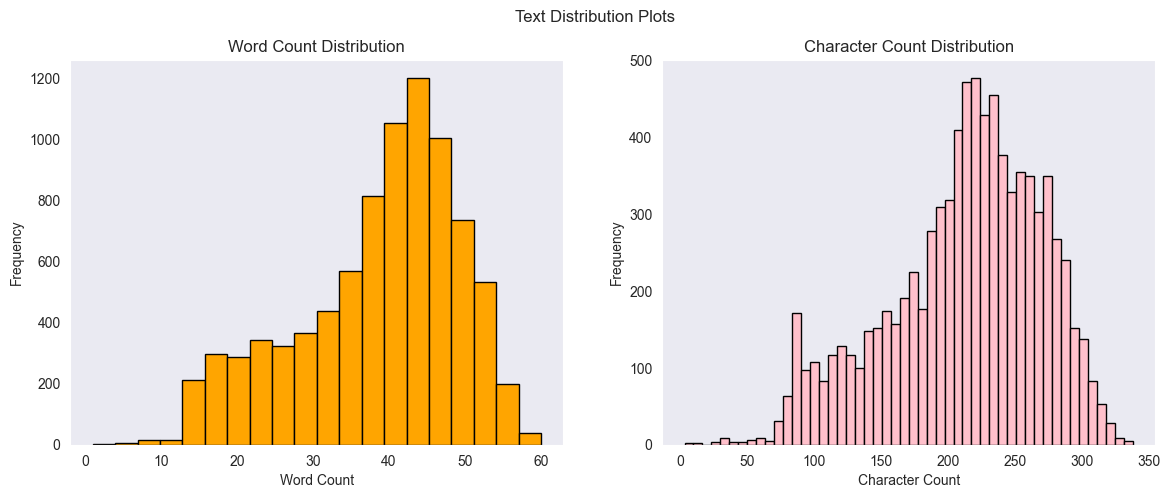

In [28]:
# Plot statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=20, color= 'orange', edgecolor='black')
axes[0].grid(False)
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['char_count'], bins=50, color='pink', edgecolor='black')
axes[1].grid(False)
axes[1].set_title('Character Count Distribution')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

fig.suptitle('Text Distribution Plots')
plt.show()

We have that there is an average word count of ~39 words per customer feedback ticket, with most falling between 30-50 words. Character count follows a similar distribution with an average of ~212 characters per feedback ticket.

## Step 5: Label Frequency Analysis

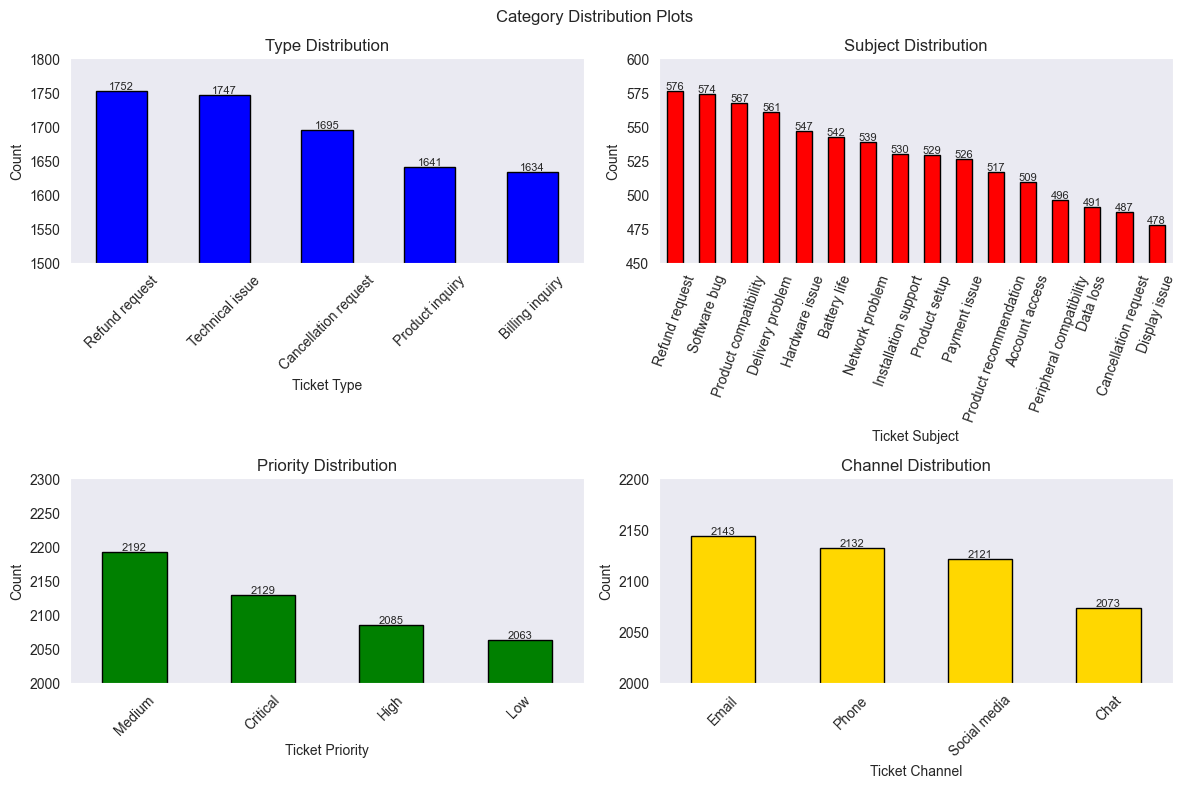

In [55]:
# ticket type counts and ticket subject counts --> plot w layered bar graph
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Ticket Type distribution
df['Ticket Type'].value_counts().plot(kind='bar', ax=axes[0, 0], color='blue', edgecolor='black')
axes[0, 0].set_title('Type Distribution')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylim(1500, 1800)

# Ticket Subject distribution
df['Ticket Subject'].value_counts().plot(kind='bar', ax=axes[0, 1], color='red', edgecolor='black')
axes[0, 1].set_title('Subject Distribution')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=70)
axes[0,1].set_ylim(450, 600)

# Ticket Priority distribution
df['Ticket Priority'].value_counts().plot(kind='bar', ax=axes[1, 0], color='green', edgecolor='black')
axes[1, 0].set_title('Priority Distribution')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylim(2000, 2300)

# Ticket Channel Distribution
df['Ticket Channel'].value_counts().plot(kind='bar', ax=axes[1, 1], color='gold', edgecolor='black')
axes[1, 1].set_title('Channel Distribution')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1,1].set_ylim(2000, 2200)

fig.suptitle('Category Distribution Plots')
for ax in axes.flatten():
    ax.grid(False)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

We can see a relatively even distribution of label categories across the data. Whilst each category has a notable most common category, they do not dominate. Refund requests are both the most common ticket type and ticket subject. Most tickets are given medium priority and most are submitted through the email channel.

## Step 6: Word frequency analysis

In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

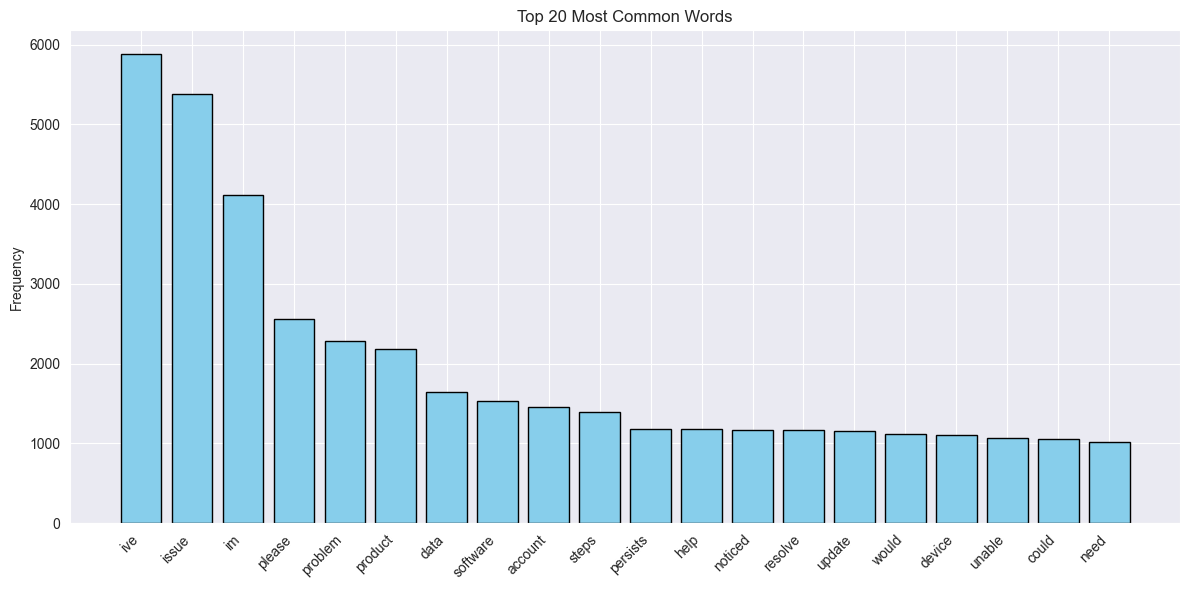

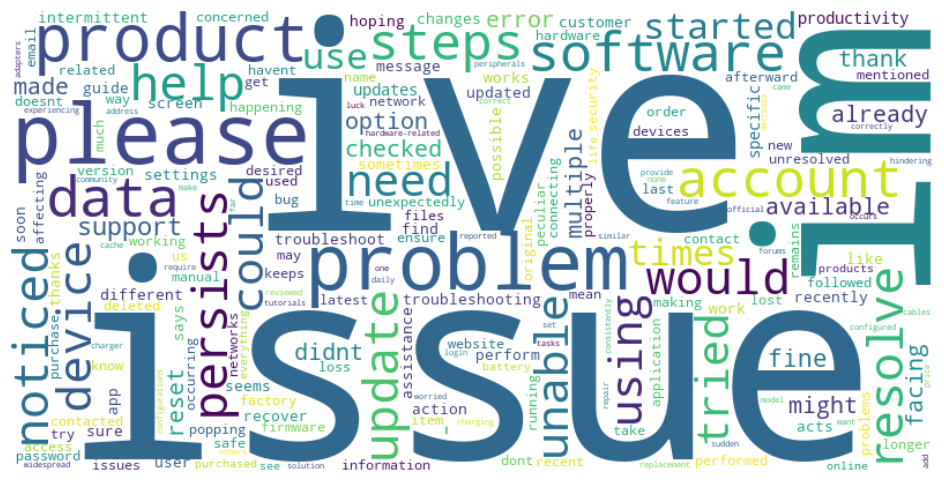

In [66]:
def tokenize_and_remove_stopwords(text):
    words = str(text).lower().split()   # simple tokenization
    words = [w for w in words if w not in stop_words]
    return words

# Apply to your DataFrame
df['tokens'] = df['clean_text'].apply(tokenize_and_remove_stopwords)

all_words = [word for tokens in df['tokens'] for word in tokens]

#  Most common 20 words
word_counts = Counter(all_words)
top_words = word_counts.most_common(20)
words,counts = zip(*top_words)

plt.figure(figsize=(12,6))
plt.bar(words, counts, color='skyblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.title('Top 20 Most Common Words')
plt.tight_layout()
plt.show()

# Create word cloud
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(word_counts)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


## Step 7: Customer Satisfaction Analysis

                          mean  count       std
Ticket Type                                    
Billing inquiry       3.027574    544  1.404142
Cancellation request  3.029070    516  1.433689
Product inquiry       3.016886    533  1.366110
Refund request        2.934564    596  1.427490
Technical issue       2.958621    580  1.403799


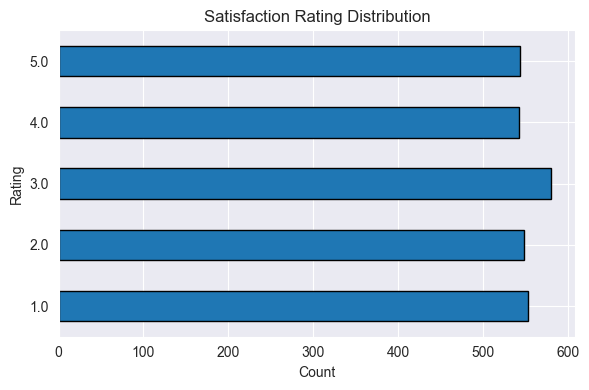

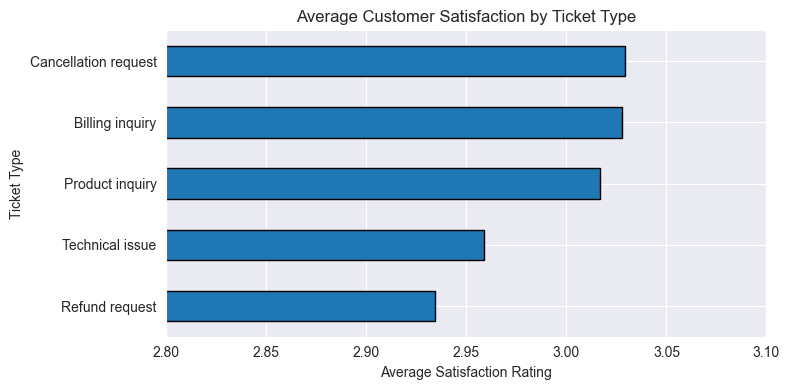

In [57]:
print(df.groupby('Ticket Type')['Customer Satisfaction Rating'].agg(['mean', 'count', 'std']))

# Satisfaction rating distribution
plt.figure(figsize=(6, 4))
df['Customer Satisfaction Rating'].value_counts().sort_index().plot(
    kind='barh', edgecolor='black')
plt.title("Satisfaction Rating Distribution")
plt.ylabel("Rating")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

# satisfaction by ticket type
sat_by_type = df.groupby('Ticket Type')['Customer Satisfaction Rating'].mean()
plt.figure(figsize=(8, 4))
sat_by_type.sort_values().plot(kind='barh',edgecolor='black')
plt.title("Average Customer Satisfaction by Ticket Type")
plt.xlabel("Average Satisfaction Rating")
plt.xlim(2.8, 3.1)
plt.tight_layout()
plt.show()